## Autoencoder on initial scRNA-seq data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import os
import glob
import functools

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.data import random_split

import ray
from ray import tune
from ray.tune import Checkpoint
from ray.tune.schedulers import ASHAScheduler

# Set seed
torch.manual_seed(111)
np.random.seed(111)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


2026-04-21 22:35:15,426	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-21 22:35:16,188	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Using device: cpu


We begin by loading the scRNA-seq tsv files as dataframes.

In [2]:
# Single-cell path
sc_path = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/scRNA-seq/"

# List files, obtain paths, then read as dfs
sc_files     = os.listdir(sc_path)
sc_filenames = ["".join([sc_path, "/" , tsv]) for tsv in sc_files]
sc_dfs       = [pd.read_table(tsv, sep = "\t", index_col = 0) for tsv in sc_filenames] # tsv

We then concatenate everything into a single dataframe, then convert to torch tensor for training.

In [3]:
# Concatenate all dataframes
sc_data = pd.concat(sc_dfs, axis = 1, join = "outer")

# Replace NaNs with 0
sc_data.fillna(0, inplace = True)

# Convert to torch tensor
sc_data = torch.tensor(sc_data.values).T

# Check dims and other stats*
print(f"Data dims : {sc_data.shape}")
print(f"# Cells   : {sc_data.shape[0]}")
print(f"# Genes   : {sc_data.shape[1]}")

Data dims : torch.Size([40000, 2007])
# Cells   : 40000
# Genes   : 2007


Convert stuff to TPMs, because this is the input our CFU regressor uses.

In [5]:
# How to convert stuff to TPM values?

Let's build a simple autoencoder with 2 hidden layers and RELU activation all around.

In [6]:
class simpleAE(nn.Module):
    # Simple AE with 2 hidden layers
    def __init__(self, input_dim, h1, h2, latent_dim):
        super().__init__()
        # Encoder layers
        self.enc_fc1    = nn.Linear(input_dim, h1)
        self.enc_fc2    = nn.Linear(h1, h2)
        self.enc_latent = nn.Linear(h2, latent_dim)
        # Decoder layers
        self.dec_fc1    = nn.Linear(latent_dim, h2)
        self.dec_fc2    = nn.Linear(h2, h1)
        self.dec_out    = nn.Linear(h1, input_dim)

    def encode(self, x):
        # Relu activation functions
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        z = self.enc_latent(h)
        return z

    def decode(self, z):
        # Relu activation functions
        h    = F.relu(self.dec_fc1(z))
        h    = F.relu(self.dec_fc2(h))
        xhat = self.dec_out(h)
        return xhat
    
    def forward(self, x):
        z    = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

Now the training.

In [7]:
def train_ae(model, X, epochs, batch_size = 64, lr = 1e-4):

    # Define dataset and batches
    dataset = TensorDataset(X)
    loader  = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    # Adam optimizer with specified LR
    optim   = torch.optim.Adam(model.parameters(), lr=lr)

    # List to store loss over time
    losses  = []

    # Epochs
    for epoch in range(epochs):

        # Initialize epoch loss
        epoch_loss = 0.0

        # Batch (each is a tuple (x,) since we have no labels y)
        for batch_tuple in loader:

            # Single batch
            (xb,) = batch_tuple
            xb = xb.to(device).float()

            # Generate predicted x
            xhat, _ = model(xb)

            # Calculate loss
            loss = F.mse_loss(xhat, xb)

            # Clear gradient, backprop, update parmaeters
            optim.zero_grad(); loss.backward(); optim.step()

            # Total loss = average batch loss * batch size
            epoch_loss += loss.item() * xb.size(0)

        # Compute average 
        losses.append(epoch_loss / len(X))

        # Return loss every 10 
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d}  MSE = {losses[-1]:.4f}")
    return losses

In [8]:
# Store the number of input dimensions
num_genes = sc_data.shape[1]

# Train the autoencoder
print("Training standard autoencoder...")

# Model
ae = simpleAE(input_dim = num_genes, 
              h1 = 500, 
              h2 = 100, 
              latent_dim = 10    # Play with latent dimension*
              ).to(device)
losses = train_ae(ae, sc_data, epochs = 200)

Training standard autoencoder...


KeyboardInterrupt: 

Now, we let's define a training loop for hyperparameter tuning.

Text(0, 0.5, 'MSE loss')

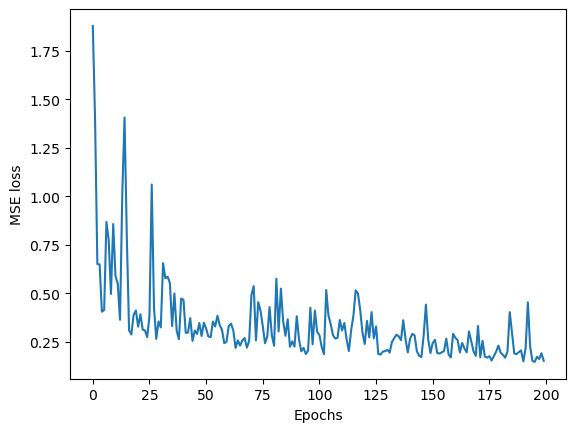

In [ ]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE loss")

Define training function for hyperparameter tuning using raytune

In [ ]:
fdsafjkda
fdsjaklafd

In [ ]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler

# Wrap training function in a function that is callable by ray tune
def train_ae_tune(X, batch_size, epochs, config):

    # Define them model
    ae = simpleAE(inpute_dim = num_genes,
                  h1 = config["h1"],
                  h2 = config["h2"],
                  latent_dim = config["latent_dim"]
                  )
    ae.to(device)

    # Define dataset and batches
    dataset = TensorDataset(X)
    loader  = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    # Adam optimizer with specified LR
    optim   = torch.optim.Adam(ae.parameters(), lr = config["lr"])

    # List to store loss over time
    losses  = []

    # Epochs
    for epoch in range(epochs):

        # Initialize epoch loss
        epoch_loss = 0.0

        # Batch (each is a tuple (x,) since we have no labels y)
        for batch_tuple in loader:

            # Single batch
            (xb,) = batch_tuple
            xb = xb.to(device).float()

            # Generate predicted x
            xhat, _ = ae(xb)

            # Calculate loss
            loss = F.mse_loss(xhat, xb)

            # Clear gradient, backprop, update parmaeters
            optim.zero_grad(); loss.backward(); optim.step()

            # Total loss = average batch loss * batch size
            epoch_loss += loss.item() * xb.size(0)

        # Compute average 
        losses.append(epoch_loss / len(X))

        # Return loss every 10 
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d}  MSE = {losses[-1]:.4f}")

    # Since unsupervised, report the last loss after training
    tune.report(loss = losses[-1])
    


# ae = simpleAE(input_dim = num_genes, h1 = 500, h2 = 100, latent_dim = 10)    # Play with latent dimension*

# def __init__(self, input_dim, h1, h2, latent_dim):



def train_ae_tune(model, X, epochs, batch_size = 64, lr = 1e-4):

    # Define dataset and batches
    dataset = TensorDataset(X)
    loader  = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    # Adam optimizer with specified LR
    optim   = torch.optim.Adam(model.parameters(), lr=lr)

    # List to store loss over time
    losses  = []

    # Epochs
    for epoch in range(epochs):

        # Initialize epoch loss
        epoch_loss = 0.0

        # Batch (each is a tuple (x,) since we have no labels y)
        for batch_tuple in loader:

            # Single batch
            (xb,) = batch_tuple
            xb = xb.to(device).float()

            # Generate predicted x
            xhat, _ = model(xb)

            # Calculate loss
            loss = F.mse_loss(xhat, xb)

            # Clear gradient, backprop, update parmaeters
            optim.zero_grad(); loss.backward(); optim.step()

            # Total loss = average batch loss * batch size
            epoch_loss += loss.item() * xb.size(0)

        # Compute average 
        losses.append(epoch_loss / len(X))

        # Return loss every 10 
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch+1:3d}  MSE = {losses[-1]:.4f}")
    return losses

Plot loss function over time.

Observe latent space embeddings

In [ ]:
# Extract latent space by using encoder block
ae.eval()
with torch.no_grad():
    z = ae.encode(sc_data.float().to(device)).cpu().numpy()

# Plot latent space
z.shape

(60000, 10)